# 🔍 Smart Customer Churn Intelligence Platform
## Model Training Notebook — Google Colab

**Business Problem:**
A telecom operator is losing ~26% of customers annually with no early-warning system.
This notebook builds an XGBoost churn classifier trained on 7,000+ customer records.
The trained model artifact is exported to Google Cloud Storage for real-time inference
via Cloud Functions — no Vertex AI required, fully free-tier compatible.

**Notebook Sections:**
1. Environment Setup
2. Data Loading & Exploration
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training & Evaluation
6. Export Model Artifact to GCS

In [ ]:
# Install GCP client library (Colab doesn't have it by default)
!pip install google-cloud-storage xgboost scikit-learn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

print("All libraries loaded ✓")

All libraries loaded ✓


## 1. Data Loading
Upload `telco_churn.csv` using the files panel on the left, or load from Drive.

In [ ]:
# Option A: Upload directly in Colab (simplest)
from google.colab import files

print("Upload your telco_churn.csv file:")
uploaded = files.upload()  # A file picker will appear

df = pd.read_csv(list(uploaded.keys())[0])
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Upload your telco_churn.csv file:


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset loaded: 7043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploratory Data Analysis

In [ ]:
print("=== DATASET INFO ===")
print(f"Shape: {df.shape}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nData types:")
print(df.dtypes.value_counts())

=== DATASET INFO ===
Shape: (7043, 21)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%

Missing values:
Series([], dtype: int64)

Data types:
object     18
int64       2
float64     1
Name: count, dtype: int64


In [ ]:
# TotalCharges has blank strings for new customers (tenure=0)
# This is the same defensive parsing we use in our BigQuery SQL
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# Fill NaN TotalCharges with 0 (new customers have no charges yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"TotalCharges nulls after fix: {df['TotalCharges'].isnull().sum()}")
print(f"Sample TotalCharges: {df['TotalCharges'].head().values}")

TotalCharges nulls after fix: 0
Sample TotalCharges: [  29.85 1889.5   108.15 1840.75  151.65]


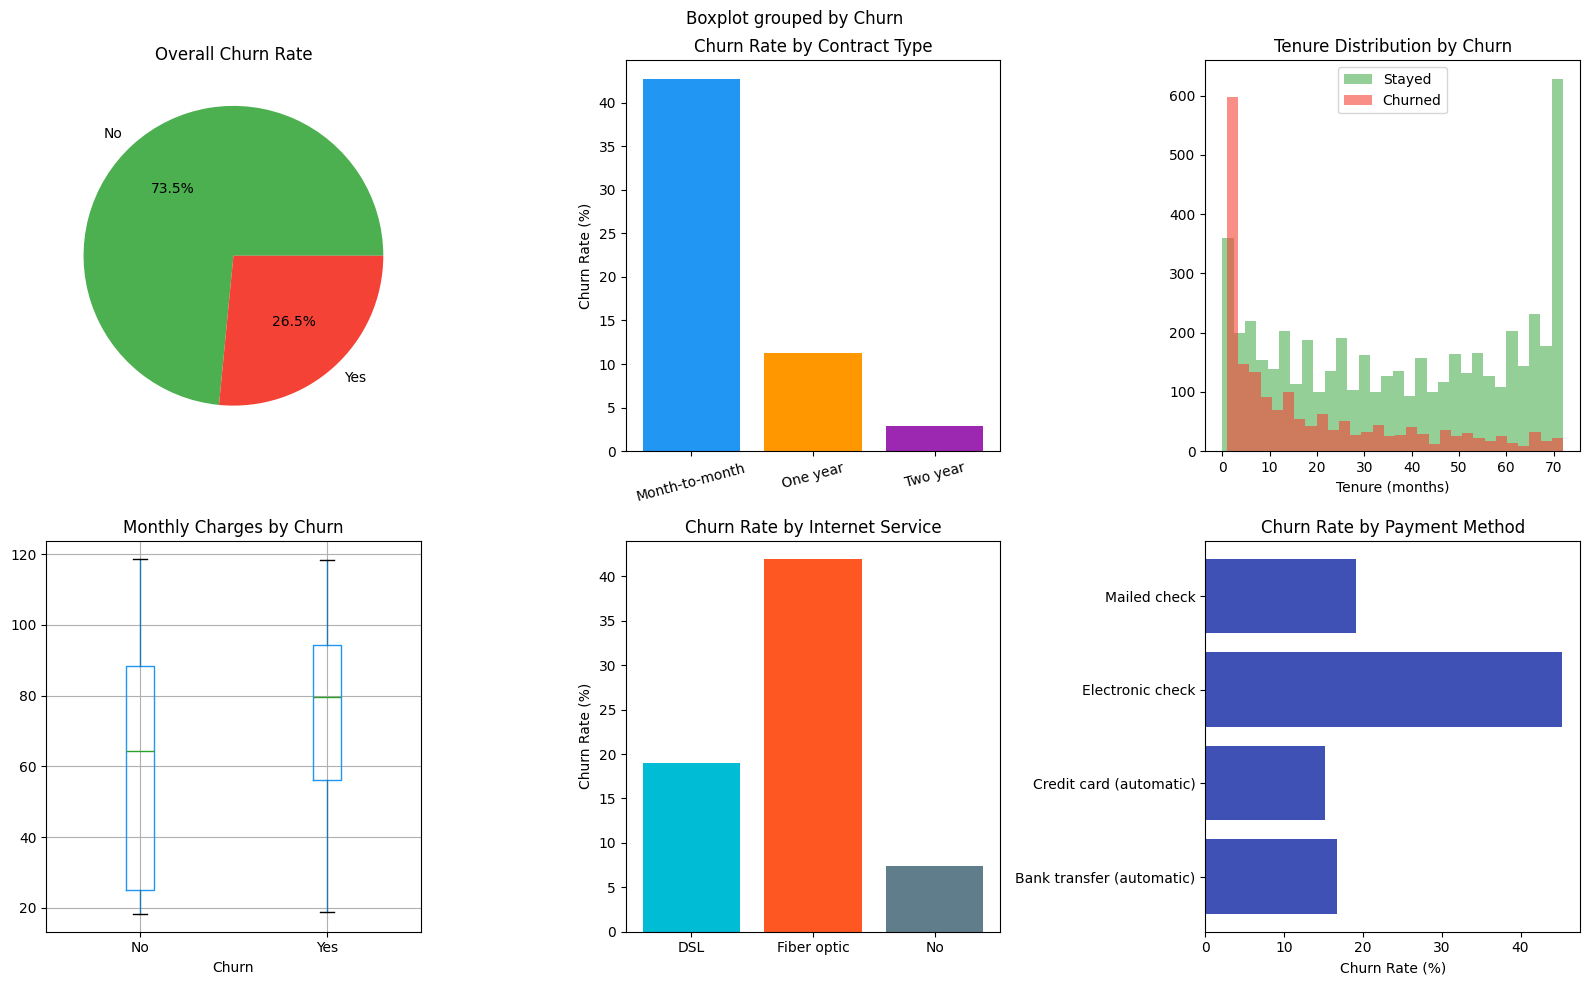

EDA chart saved as churn_eda.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Churn Analysis — Key Drivers', fontsize=16, fontweight='bold')

# 1. Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0,0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
              colors=['#4CAF50', '#F44336'])
axes[0,0].set_title('Overall Churn Rate')

# 2. Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
axes[0,1].bar(contract_churn['Contract'], contract_churn['Churn'],
              color=['#2196F3', '#FF9800', '#9C27B0'])
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Tenure distribution by churn
churned = df[df['Churn'] == 'Yes']['tenure']
stayed = df[df['Churn'] == 'No']['tenure']
axes[0,2].hist(stayed, bins=30, alpha=0.6, label='Stayed', color='#4CAF50')
axes[0,2].hist(churned, bins=30, alpha=0.6, label='Churned', color='#F44336')
axes[0,2].set_title('Tenure Distribution by Churn')
axes[0,2].set_xlabel('Tenure (months)')
axes[0,2].legend()

# 4. Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1,0],
           boxprops=dict(color='#2196F3'))
axes[1,0].set_title('Monthly Charges by Churn')
axes[1,0].set_xlabel('Churn')

# 5. Churn by Internet Service
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
axes[1,1].bar(internet_churn['InternetService'], internet_churn['Churn'],
              color=['#00BCD4', '#FF5722', '#607D8B'])
axes[1,1].set_title('Churn Rate by Internet Service')
axes[1,1].set_ylabel('Churn Rate (%)')

# 6. Payment Method vs Churn
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
axes[1,2].barh(payment_churn['PaymentMethod'], payment_churn['Churn'],
               color='#3F51B5')
axes[1,2].set_title('Churn Rate by Payment Method')
axes[1,2].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA chart saved as churn_eda.png")

## 3. Feature Engineering
Same logic as our BigQuery SQL views — replicated here for model training.

In [ ]:
df_model = df.copy()

# Target variable
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

# Drop customerID — not a feature
df_model.drop('customerID', axis=1, inplace=True)

# Encode binary yes/no columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df_model[col] = df_model[col].map(
        {'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0}
    )

# Encode gender
df_model['gender'] = (df_model['gender'] == 'Male').astype(int)

# Label encode multi-class categoricals
le = LabelEncoder()
for col in ['InternetService', 'Contract', 'PaymentMethod']:
    df_model[col] = le.fit_transform(df_model[col])

# Feature: charge per month of tenure (value metric)
df_model['charge_per_tenure'] = df_model['MonthlyCharges'] / (df_model['tenure'] + 1)

# Feature: tenure bucket (mirrors our BigQuery SQL bucketing)
df_model['tenure_bucket'] = pd.cut(df_model['tenure'],
    bins=[0, 12, 24, 48, 72], labels=[0, 1, 2, 3],include_lowest=True).astype(int)

print(f"Features ready: {df_model.shape[1] - 1} features + 1 target")
print(f"Feature columns: {list(df_model.columns)}")

Features ready: 21 features + 1 target
Feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'charge_per_tenure', 'tenure_bucket']


## 4. Model Training — XGBoost Classifier
XGBoost is chosen for its strong performance on tabular data with class imbalance,
and because BigQuery ML uses the same algorithm under the hood (BOOSTED_TREE_CLASSIFIER).

In [ ]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Churn rate in train: {y_train.mean():.1%} | test: {y_test.mean():.1%}")

# scale_pos_weight handles class imbalance
# (ratio of non-churners to churners)
scale = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\nModel training complete ✓")

Train size: 5634 | Test size: 1409
Churn rate in train: 26.5% | test: 26.5%
[0]	validation_0-logloss:0.67682
[50]	validation_0-logloss:0.49393
[100]	validation_0-logloss:0.48695
[150]	validation_0-logloss:0.48542
[199]	validation_0-logloss:0.48483

Model training complete ✓


=== MODEL PERFORMANCE ===
ROC-AUC Score: 0.8413

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.74      0.81      1035
     Churned       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



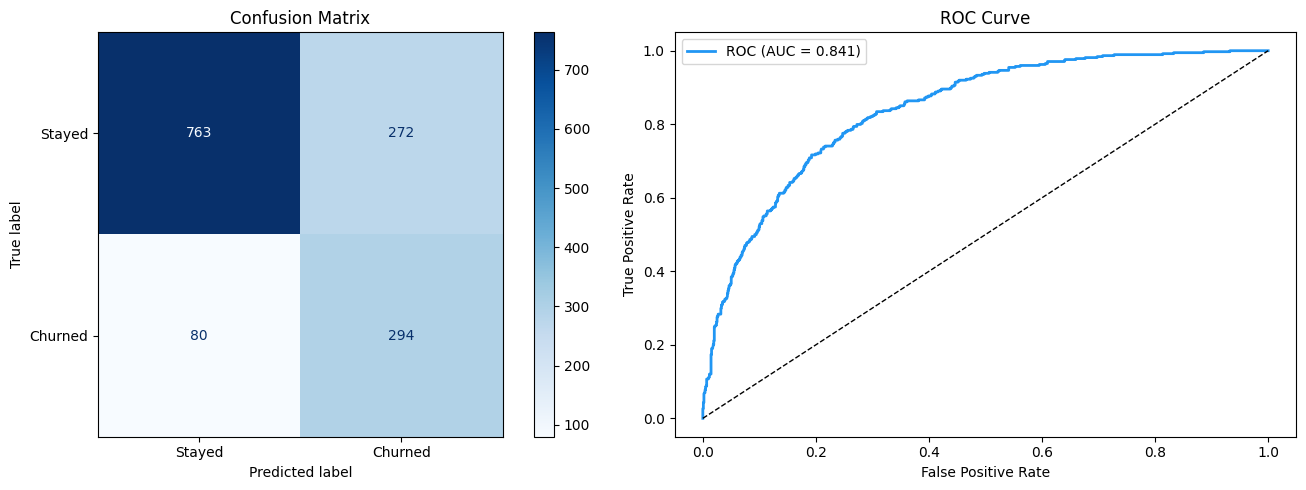

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== MODEL PERFORMANCE ===")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Stayed', 'Churned'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2,
             label=f'ROC (AUC = {roc_auc_score(y_test, y_prob):.3f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

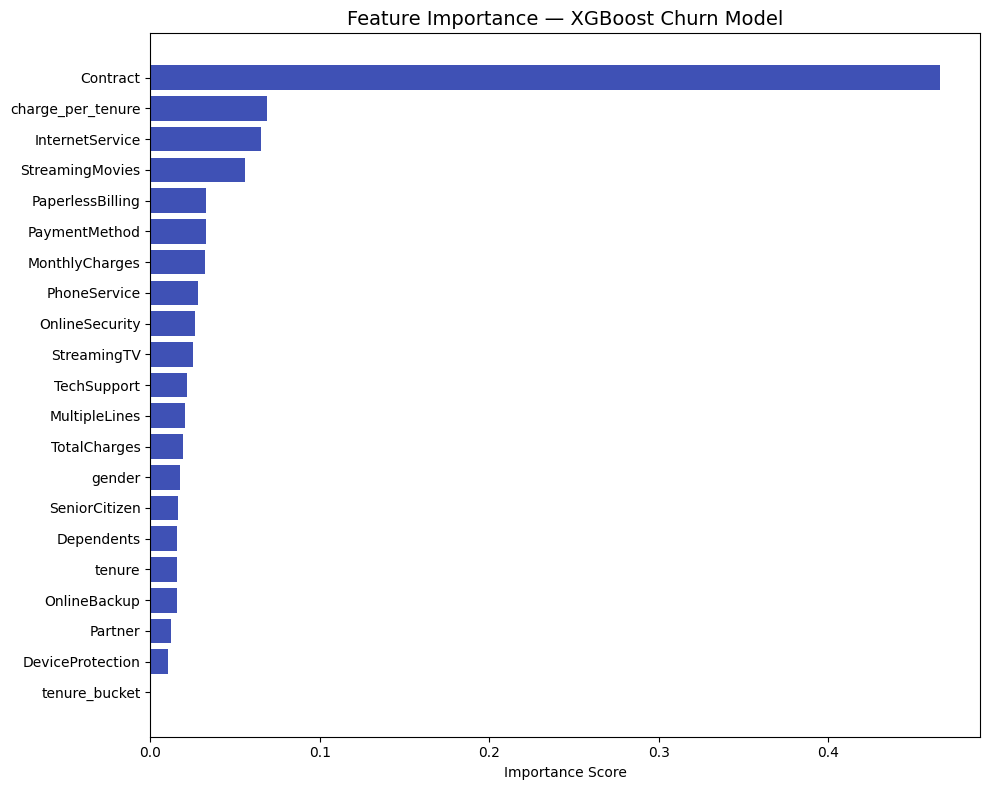


Top 5 churn predictors:
          feature  importance
 PaperlessBilling    0.033036
  StreamingMovies    0.056044
  InternetService    0.065241
charge_per_tenure    0.068643
         Contract    0.466326


In [ ]:
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='#3F51B5')
plt.title('Feature Importance — XGBoost Churn Model', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 churn predictors:")
print(feat_imp.tail(5)[['feature', 'importance']].to_string(index=False))

## 5. Export Model Artifact to Cloud Storage
The trained model is saved as a `.joblib` file and uploaded to GCS.
The Cloud Function loads this artifact at inference time —
equivalent to Vertex AI custom prediction, fully free-tier compatible.

In [ ]:
import joblib
import os

MODEL_FILENAME = "churn_model.joblib"
FEATURE_FILENAME = "feature_columns.joblib"

# Save model locally
joblib.dump(model, MODEL_FILENAME)

# Save feature column order — Cloud Function needs this to align inputs
feature_columns = list(X.columns)
joblib.dump(feature_columns, FEATURE_FILENAME)

print(f"Model saved: {MODEL_FILENAME}")
print(f"Feature columns saved: {feature_columns}")
print(f"\nModel size: {os.path.getsize(MODEL_FILENAME) / 1024:.1f} KB")
print("\nArtifact export complete ✓")

Model saved: churn_model.joblib
Feature columns saved: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'charge_per_tenure', 'tenure_bucket']

Model size: 315.2 KB

Artifact export complete ✓


In [ ]:
from google.colab import files
files.download("churn_model.joblib")
files.download("feature_columns.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>